# Entropy vs. LLM-judge degeneration labels

This notebook first reproduces the entropy summaries from `inspect_dataset.ipynb`, then evaluates whether a persistent entropy drop can detect degeneration and locate its onset. The descriptive study uses every labeled rollout. The LLM-judge study combines currently judged truncated rollouts with historically judged natural-EOS rollouts, and separates threshold calibration from final evaluation by prompt. No dataset files are modified.

## 1. Definitions

For token-level entropy $H_t$, define the persistent drop at boundary $t$ using adjacent 64-token windows:

$$\Delta H_t = \operatorname{mean}(H_{t-64:t}) - \operatorname{mean}(H_{t:t+64}).$$

The entropy onset $o_H$ is the boundary with the largest drop, and $s_H=\max(0,\max_t \Delta H_t)$ is the completion-level score. For each evaluated dataset build, prompts are deterministically divided 50/50 into calibration and test sets. A threshold $\tau$ is selected only on calibration by maximizing balanced accuracy against `is_degenerating`; ties select the higher threshold. It is then applied unchanged to test.

For a judge-positive rollout whose `onset_quote` is found in the generated tokens, signed onset distance is

$$d=o_{\mathrm{LLM}}-o_H.$$

Thus $d>0$ means the entropy rule fires earlier than the judge. Binary and onset results are reported only on test. Onset evaluation additionally requires a positive entropy prediction and a locatable judge quote. SFT-256k has no historically judged natural-EOS rows, so it remains in the descriptive study but is excluded from threshold calibration and evaluation.

In [9]:
import hashlib
import os
from pathlib import Path

SHARED_HF_CACHE = Path("/capstor/scratch/cscs/mdenegri/degeneration-probe/hf_cache")
if SHARED_HF_CACHE.exists():
    os.environ.setdefault("HF_HOME", str(SHARED_HF_CACHE))
    os.environ.setdefault("HF_HUB_CACHE", str(SHARED_HF_CACHE))
os.environ.setdefault("HF_HUB_OFFLINE", "1")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from transformers import AutoTokenizer

from degeneration_probe.utils.tokenization import find_string_in_tokens

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 100)

DATA_ROOT = Path("/capstor/store/cscs/swissai/infra01/users/mdenegri/degeneration-probe")
DATASETS = {
    "Apertus-8B-Instruct": {
        "root": DATA_ROOT / "degeneration-dataset-apertus-8b-instruct",
        "tokenizer": "swiss-ai/Apertus-8B-Instruct-2509",
    },
    "Apertus 1.5 - capfilter-linear": {
        "root": DATA_ROOT / "degeneration-dataset-apertus1p5-capfilter-linear-it8816",
        "tokenizer": "/capstor/store/cscs/swissai/infra01/reasoning/models/tokenizers/apertus_emu3.5_wavtok_text_only",
    },
    "Apertus 1.5 - SFT-256k": {
        "root": DATA_ROOT / "degeneration-dataset-apertus1p5-sft256k-4200",
        "tokenizer": "/capstor/store/cscs/swissai/infra01/reasoning/models/tokenizers/apertus_emu3.5_wavtok_text_only",
    },
}
JUDGE_BACKEND = "claude_agent_sdk"
EVALUATED_DATASETS = ["Apertus-8B-Instruct", "Apertus 1.5 - capfilter-linear"]
WINDOW = 64
EXPECTED_MAX_TOKENS = 4096
KEY = ["prompt_id", "rollout_idx"]

## 2. Load all entropy labels

In [10]:
def read_domain_shards(root, kind, columns):
    frames = []
    for path in sorted((root / kind).glob("*/shard_*.parquet")):
        frame = pd.read_parquet(path, columns=columns)
        frame["domain"] = path.parent.name
        frames.append(frame)
    if not frames:
        raise FileNotFoundError(f"No {kind} shards found below {root}")
    result = pd.concat(frames, ignore_index=True)
    assert not result.duplicated(KEY).any(), f"Duplicate keys in {kind} shards"
    return result


all_labels = {}
for model, spec in DATASETS.items():
    labels = read_domain_shards(spec["root"], "labels", KEY + ["entropy"])
    labels["mean_entropy"] = labels["entropy"].apply(
        lambda values: float(np.mean(np.asarray(values, dtype=float)))
    )
    all_labels[model] = labels
    print(f"{model}: {len(labels):,} labeled rollouts")

Apertus-8B-Instruct: 36,300 labeled rollouts
Apertus 1.5 - capfilter-linear: 36,300 labeled rollouts
Apertus 1.5 - SFT-256k: 36,300 labeled rollouts


## 3. Descriptive entropy results

The tables below reproduce the `inspect_dataset.ipynb` aggregation: first compute mean entropy per rollout, then report its mean, maximum, and minimum within each domain. The boxplots add a compact view of the full per-rollout distributions.

[Apertus-8B-Instruct]


,mean,max,min
domain,,,
aime_2025,0.427700,0.966822,0.016300
codeforces,0.358503,1.004798,0.009439
deepmath_103k,0.414214,1.317496,0.012662
if_sft_data_verified,0.617717,4.593693,0.004877
llama_nemotron,0.435042,1.097740,0.006070
medical_o1,0.818040,1.641292,0.073178
numinamath_1_5,0.373331,1.347791,0.006872


[Apertus 1.5 - capfilter-linear]


,mean,max,min
domain,,,
aime_2025,0.174721,0.491418,0.031722
codeforces,0.251631,0.690874,0.009281
deepmath_103k,0.270388,1.045154,0.030188
if_sft_data_verified,0.621972,4.356446,0.002772
llama_nemotron,0.256914,1.077006,0.010899
medical_o1,0.564922,3.253996,0.018185
numinamath_1_5,0.330944,1.866546,0.007937


[Apertus 1.5 - SFT-256k]


,mean,max,min
domain,,,
aime_2025,0.260344,1.007261,0.032535
codeforces,0.256781,0.752959,0.009742
deepmath_103k,0.350859,1.836448,0.019784
if_sft_data_verified,0.643011,4.966056,0.001506
llama_nemotron,0.248608,0.799281,0.016623
medical_o1,0.924167,3.539158,0.017115
numinamath_1_5,0.316581,1.970370,0.013782


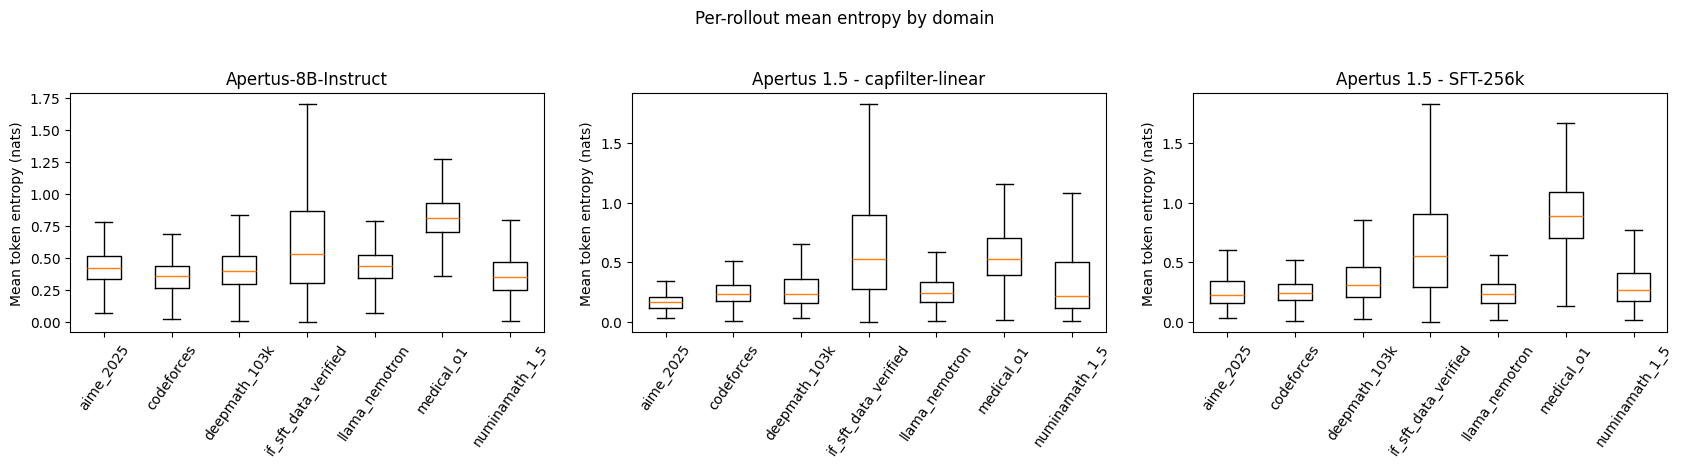

In [11]:
entropy_summary_frames = []
for model, labels in all_labels.items():
    summary = labels.groupby("domain")["mean_entropy"].agg(mean="mean", max="max", min="min")
    summary.insert(0, "dataset_build", model)
    entropy_summary_frames.append(summary.reset_index())
    print(f"[{model}]")
    display(summary.drop(columns="dataset_build"))

entropy_summary_df = pd.concat(entropy_summary_frames, ignore_index=True)

fig, axes = plt.subplots(1, len(DATASETS), figsize=(17, 4.5), sharey=False)
for ax, (model, labels) in zip(axes, all_labels.items()):
    domains = sorted(labels["domain"].unique())
    values = [labels.loc[labels["domain"].eq(domain), "mean_entropy"] for domain in domains]
    ax.boxplot(values, tick_labels=domains, showfliers=False)
    ax.set_title(model)
    ax.set_ylabel("Mean token entropy (nats)")
    ax.tick_params(axis="x", rotation=55)
fig.suptitle("Per-rollout mean entropy by domain", y=1.03)
fig.tight_layout()
plt.show()

## 4. Calibration and test LLM-judge populations

For the two evaluated builds, all successful verdicts are joined back to the current generation and label shards. This recovers historically judged natural-EOS rollouts alongside the currently judged truncated rollouts. Rows shorter than 128 tokens are reported and excluded because they cannot contain two complete 64-token windows; they are never silently treated as negative. These historical EOS rows were heuristically flagged when sampled, rather than drawn randomly, so the resulting test set is useful for discrimination but is not prevalence-representative. Prompts are assigned deterministically and exclusively to calibration or test. SFT-256k is excluded because it has no historically judged EOS rows.

In [12]:
def prompt_split(prompt_id):
    digest = hashlib.sha256(f"entropy-inspection-v1:{prompt_id}".encode()).digest()
    return "test" if int.from_bytes(digest[:8], "big") < 2**63 else "calibration"


def load_evaluation_population(model, spec):
    root = spec["root"]
    judge_all = pd.read_parquet(root / f"llm_judge/results_{JUDGE_BACKEND}.parquet")
    judge = judge_all[judge_all["status"].eq("ok")].copy()
    assert not judge.duplicated(KEY).any(), "Duplicate successful judge keys"

    generations = read_domain_shards(
        root, "generations", KEY + ["generated_token_ids", "num_tokens", "stop_reason"],
    )
    labels = all_labels[model]
    population = judge[KEY + ["is_degenerating", "onset_quote", "confidence"]].merge(
        generations[KEY + ["generated_token_ids", "num_tokens", "stop_reason", "domain"]],
        on=KEY, how="inner", validate="one_to_one",
    ).merge(labels[KEY + ["entropy"]], on=KEY, how="inner", validate="one_to_one")
    assert len(population) == len(judge), "Some historical judge keys are absent from current shards"
    assert population["stop_reason"].isin(["eos", "length"]).all()
    assert all(len(ids) == len(entropy) == n for ids, entropy, n in zip(
        population["generated_token_ids"], population["entropy"], population["num_tokens"]
    )), "Token IDs and entropy are not aligned"

    population["is_degenerating"] = population["is_degenerating"].astype(bool)
    eligibility = {
        "dataset_build": model, "judge_ok_joined": len(population),
        "too_short_for_two_windows": int(population["num_tokens"].lt(2 * WINDOW).sum()),
    }
    population = population[population["num_tokens"].ge(2 * WINDOW)].copy()
    eligibility["entropy_eligible"] = len(population)
    population["stratum"] = np.where(
        population["stop_reason"].eq("eos"), "historical_flagged_natural_eos", "truncated"
    )
    population["evaluation_split"] = population["prompt_id"].map(prompt_split)
    calibration_prompts = set(population.loc[population["evaluation_split"].eq("calibration"), "prompt_id"])
    test_prompts = set(population.loc[population["evaluation_split"].eq("test"), "prompt_id"])
    assert calibration_prompts.isdisjoint(test_prompts), "Prompt leakage across splits"
    for split in ["calibration", "test"]:
        assert population.loc[population["evaluation_split"].eq(split), "is_degenerating"].nunique() == 2
    return population, eligibility


populations = {}
eligibility_rows = []
for model in EVALUATED_DATASETS:
    populations[model], eligibility = load_evaluation_population(model, DATASETS[model])
    eligibility_rows.append(eligibility)
eligibility_df = pd.DataFrame(eligibility_rows).set_index("dataset_build")
display(eligibility_df)
composition_df = pd.concat([
    population.groupby(["evaluation_split", "stratum", "is_degenerating"]).size().rename("n").reset_index().assign(dataset_build=model)
    for model, population in populations.items()
], ignore_index=True)
display(composition_df.pivot_table(
    index=["dataset_build", "evaluation_split", "stratum"],
    columns="is_degenerating", values="n", fill_value=0,
).rename(columns={False: "judge_negative", True: "judge_positive"}))
print("Apertus 1.5 - SFT-256k: descriptive entropy only; excluded from judge evaluation (no historical EOS verdicts).")

,judge_ok_joined,too_short_for_two_windows,entropy_eligible
dataset_build,,,
Apertus-8B-Instruct,1170,10,1160
Apertus 1.5 - capfilter-linear,2837,13,2824


is_degenerating                                                                 judge_negative  \
dataset_build                  evaluation_split stratum                                          
Apertus 1.5 - capfilter-linear calibration      historical_flagged_natural_eos           716.0   
                                                truncated                                  4.0   
                               test             historical_flagged_natural_eos           651.0   
                                                truncated                                  2.0   
Apertus-8B-Instruct            calibration      historical_flagged_natural_eos           114.0   
                                                truncated                                  5.0   
                               test             historical_flagged_natural_eos            94.0   
                                                truncated                                  3.0   

is_degenerating                                                                 judge_positive  
dataset_build                  evaluation_split stratum                                         
Apertus 1.5 - capfilter-linear calibration      historical_flagged_natural_eos            87.0  
                                                truncated                                692.0  
                               test             historical_flagged_natural_eos            92.0  
                                                truncated                                580.0  
Apertus-8B-Instruct            calibration      historical_flagged_natural_eos            80.0  
                                                truncated                                428.0  
                               test             historical_flagged_natural_eos            45.0  
                                                truncated                                391.0

Apertus 1.5 - SFT-256k: descriptive entropy only; excluded from judge evaluation (no historical EOS verdicts).


## 5. Persistent entropy-drop rule

In [13]:
def persistent_entropy_drop(entropy, window=WINDOW):
    values = np.asarray(entropy, dtype=float)
    if len(values) < 2 * window or not np.isfinite(values).all():
        return np.nan, np.nan
    cumulative = np.concatenate(([0.0], np.cumsum(values)))
    boundaries = np.arange(window, len(values) - window + 1)
    before = (cumulative[boundaries] - cumulative[boundaries - window]) / window
    after = (cumulative[boundaries + window] - cumulative[boundaries]) / window
    drops = before - after
    best = int(np.argmax(drops))
    return int(boundaries[best]), float(max(0.0, drops[best]))


# Deterministic checks: no drop, a known step, and insufficient context.
onset, score = persistent_entropy_drop(np.ones(256))
assert onset == WINDOW and score == 0.0
step = np.r_[np.ones(128), np.zeros(128)]
assert persistent_entropy_drop(step) == (128, 1.0)
assert all(np.isnan(x) for x in persistent_entropy_drop(np.ones(100)))

for model, population in populations.items():
    estimates = population["entropy"].apply(persistent_entropy_drop)
    population[["entropy_onset", "entropy_drop_score"]] = pd.DataFrame(
        estimates.tolist(), index=population.index
    )
    assert population[["entropy_onset", "entropy_drop_score"]].notna().all().all()

## 6. Binary detection

Entropy is the prediction and the LLM judge is the reference. Each model-specific threshold is selected on calibration by maximizing balanced accuracy, then applied unchanged to test. The table contains test metrics only.

,threshold,judge_positive_rate,entropy_positive_rate,n,TP,FP,TN,FN,precision,recall,f1,specificity,balanced_accuracy,mcc,accuracy,all_positive_f1,all_positive_balanced_accuracy,all_positive_mcc
dataset_build,,,,,,,,,,,,,,,,,,
Apertus-8B-Instruct,0.4835,81.8%,65.5%,533,304,45,52,132,0.871,0.697,0.775,0.536,0.617,0.189,0.668,0.900,0.500,0.000
Apertus 1.5 - capfilter-linear,0.4456,50.7%,46.0%,1325,435,174,479,237,0.714,0.647,0.679,0.734,0.690,0.382,0.690,0.673,0.500,0.000


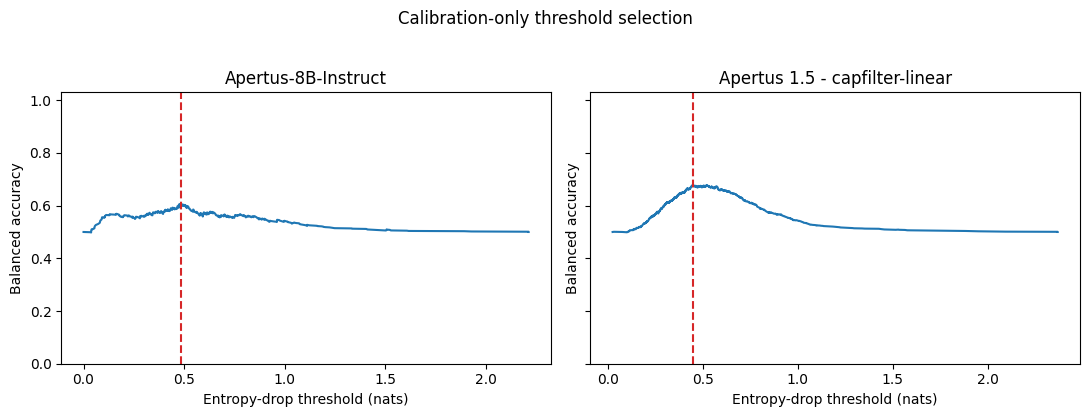

In [14]:
def safe_ratio(numerator, denominator):
    return numerator / denominator if denominator else np.nan


def confusion_metrics(truth, prediction):
    truth = np.asarray(truth, dtype=bool)
    prediction = np.asarray(prediction, dtype=bool)
    tp = int(np.sum(prediction & truth))
    fp = int(np.sum(prediction & ~truth))
    tn = int(np.sum(~prediction & ~truth))
    fn = int(np.sum(~prediction & truth))
    precision = safe_ratio(tp, tp + fp)
    recall = safe_ratio(tp, tp + fn)
    specificity = safe_ratio(tn, tn + fp)
    balanced_accuracy = np.nanmean([recall, specificity])
    denominator = np.sqrt((tp + fp) * (tp + fn) * (tn + fp) * (tn + fn))
    mcc = (tp * tn - fp * fn) / denominator if denominator else 0.0
    return {
        "n": len(truth), "TP": tp, "FP": fp, "TN": tn, "FN": fn,
        "precision": precision, "recall": recall,
        "f1": safe_ratio(2 * precision * recall, precision + recall),
        "specificity": specificity, "balanced_accuracy": balanced_accuracy, "mcc": mcc,
        "accuracy": safe_ratio(tp + tn, len(truth)),
    }


def select_balanced_accuracy_threshold(scores, truth):
    scores = np.asarray(scores, dtype=float)
    truth = np.asarray(truth, dtype=bool)
    unique = np.unique(scores)
    candidates = np.r_[np.nextafter(unique[0], -np.inf), unique, np.nextafter(unique[-1], np.inf)]
    rows = []
    for threshold in candidates:
        metrics = confusion_metrics(truth, scores >= threshold)
        rows.append({"threshold": threshold, **metrics})
    curve = pd.DataFrame(rows)
    best_score = curve["balanced_accuracy"].max()
    best = curve[curve["balanced_accuracy"].eq(best_score)].sort_values("threshold").iloc[-1]
    return float(best["threshold"]), curve


binary_rows = []
threshold_curves = {}
for model, population in populations.items():
    calibration = population[population["evaluation_split"].eq("calibration")]
    test = population[population["evaluation_split"].eq("test")].copy()
    threshold, curve = select_balanced_accuracy_threshold(
        calibration["entropy_drop_score"], calibration["is_degenerating"]
    )
    threshold_curves[model] = curve
    population["entropy_flag"] = population["entropy_drop_score"].ge(threshold)
    selected_metrics = confusion_metrics(
        test["is_degenerating"], test["entropy_drop_score"].ge(threshold)
    )
    all_positive_metrics = confusion_metrics(
        test["is_degenerating"], np.ones(len(test), dtype=bool)
    )
    binary_rows.append({
        "dataset_build": model, "threshold": threshold,
        "judge_positive_rate": test["is_degenerating"].mean(),
        "entropy_positive_rate": test["entropy_drop_score"].ge(threshold).mean(),
        **selected_metrics,
        "all_positive_f1": all_positive_metrics["f1"],
        "all_positive_balanced_accuracy": all_positive_metrics["balanced_accuracy"],
        "all_positive_mcc": all_positive_metrics["mcc"],
    })

binary_metrics_df = pd.DataFrame(binary_rows).set_index("dataset_build")
display(binary_metrics_df.style.format({
    "threshold": "{:.4f}", "judge_positive_rate": "{:.1%}",
    "entropy_positive_rate": "{:.1%}", "precision": "{:.3f}",
    "recall": "{:.3f}", "f1": "{:.3f}",
    "specificity": "{:.3f}", "balanced_accuracy": "{:.3f}",
    "mcc": "{:.3f}", "accuracy": "{:.3f}",
    "all_positive_f1": "{:.3f}", "all_positive_balanced_accuracy": "{:.3f}",
    "all_positive_mcc": "{:.3f}",
}))

fig, axes = plt.subplots(1, len(EVALUATED_DATASETS), figsize=(11, 4), sharey=True)
for ax, (model, curve) in zip(axes, threshold_curves.items()):
    ax.plot(curve["threshold"], curve["balanced_accuracy"])
    ax.axvline(binary_metrics_df.loc[model, "threshold"], color="tab:red", linestyle="--")
    ax.set_title(model)
    ax.set_xlabel("Entropy-drop threshold (nats)")
    ax.set_ylabel("Balanced accuracy")
    ax.set_ylim(0, 1.03)
fig.suptitle("Calibration-only threshold selection", y=1.03)
fig.tight_layout()
plt.show()

## 7. Signed onset distance

Only test rows are used. Judge-positive rows with missing or unlocatable quotes are reported as coverage loss, not converted into negatives. Judge-positive/entropy-negative rows remain false negatives in Section 6 but cannot contribute a finite onset distance.

In [15]:
_tokenizer_cache = {}


def get_tokenizer(name):
    if name not in _tokenizer_cache:
        kwargs = {"local_files_only": True}
        if not Path(name).exists() and SHARED_HF_CACHE.exists():
            kwargs["cache_dir"] = str(SHARED_HF_CACHE)
        _tokenizer_cache[name] = AutoTokenizer.from_pretrained(name, **kwargs)
    return _tokenizer_cache[name]


def locate_onset_quote(quote, generated_token_ids, tokenizer):
    if not isinstance(quote, str) or not quote:
        return np.nan
    tokens = torch.as_tensor([int(token) for token in generated_token_ids])
    try:
        return int(find_string_in_tokens(quote, tokens, tokenizer).start)
    except (AssertionError, ValueError):
        return np.nan


quote_coverage_rows = []
for model, population in populations.items():
    tokenizer = get_tokenizer(DATASETS[model]["tokenizer"])
    positive = population["evaluation_split"].eq("test") & population["is_degenerating"]
    population["llm_onset"] = np.nan
    population.loc[positive, "llm_onset"] = [
        locate_onset_quote(quote, ids, tokenizer)
        for quote, ids in zip(
            population.loc[positive, "onset_quote"],
            population.loc[positive, "generated_token_ids"],
        )
    ]
    n_positive = int(positive.sum())
    n_matched = int(population.loc[positive, "llm_onset"].notna().sum())
    quote_coverage_rows.append({
        "dataset_build": model, "judge_positive": n_positive,
        "quote_present": int(population.loc[positive, "onset_quote"].notna().sum()),
        "quote_matched": n_matched,
        "match_rate_among_judge_positive": safe_ratio(n_matched, n_positive),
    })
quote_coverage_df = pd.DataFrame(quote_coverage_rows).set_index("dataset_build")
display(quote_coverage_df.style.format({"match_rate_among_judge_positive": "{:.1%}"}))

,judge_positive,quote_present,quote_matched,match_rate_among_judge_positive
dataset_build,,,,
Apertus-8B-Instruct,436,436,436,100.0%
Apertus 1.5 - capfilter-linear,672,672,670,99.7%


,n_comparable,mean_signed_distance,median_signed_distance,mean_absolute_distance,median_absolute_distance,q25_signed,q75_signed
dataset_build,,,,,,,
Apertus-8B-Instruct,304,329.8,230.5,464.9,327.0,-28.2,682.8
Apertus 1.5 - capfilter-linear,433,307.2,103.0,357.3,157.0,-32.0,459.0


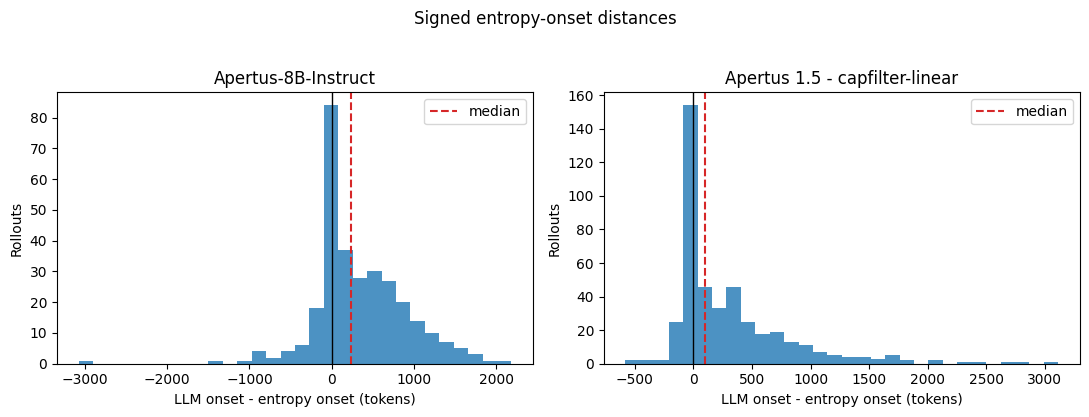

In [16]:
onset_frames = []
onset_rows = []
for model, population in populations.items():
    comparable = population[
        population["evaluation_split"].eq("test")
        & population["is_degenerating"]
        & population["entropy_flag"]
        & population["llm_onset"].notna()
    ].copy()
    comparable["signed_distance"] = comparable["llm_onset"] - comparable["entropy_onset"]
    comparable["absolute_distance"] = comparable["signed_distance"].abs()
    comparable["dataset_build"] = model
    onset_frames.append(comparable)
    signed = comparable["signed_distance"]
    absolute = comparable["absolute_distance"]
    onset_rows.append({
        "dataset_build": model, "n_comparable": len(comparable),
        "mean_signed_distance": signed.mean(),
        "median_signed_distance": signed.median(),
        "mean_absolute_distance": absolute.mean(),
        "median_absolute_distance": absolute.median(),
        "q25_signed": signed.quantile(0.25), "q75_signed": signed.quantile(0.75),
    })

onset_comparisons_df = pd.concat(onset_frames, ignore_index=True)
onset_summary_df = pd.DataFrame(onset_rows).set_index("dataset_build")
display(onset_summary_df.style.format({column: "{:.1f}" for column in onset_summary_df.columns if column != "n_comparable"}))

fig, axes = plt.subplots(1, len(EVALUATED_DATASETS), figsize=(11, 4), sharey=False)
for ax, model in zip(axes, EVALUATED_DATASETS):
    values = onset_comparisons_df.loc[onset_comparisons_df["dataset_build"].eq(model), "signed_distance"]
    ax.hist(values, bins=30, color="tab:blue", alpha=0.8)
    ax.axvline(0, color="black", linewidth=1)
    ax.axvline(values.median(), color="tab:red", linestyle="--", label="median")
    ax.set_title(model)
    ax.set_xlabel("LLM onset - entropy onset (tokens)")
    ax.set_ylabel("Rollouts")
    ax.legend()
fig.suptitle("Signed entropy-onset distances", y=1.03)
fig.tight_layout()
plt.show()

## 8. Interpretation notes

- Descriptive entropy tables and judge comparisons use different populations: all labeled rollouts versus successful historical and current verdicts for two builds.
- Thresholds are selected on calibration prompts and evaluated once on disjoint test prompts. Balanced accuracy gives equal weight to sensitivity and specificity despite class imbalance.
- Historical natural-EOS rows were heuristically flagged before judging, not sampled randomly. Test metrics therefore measure discrimination in this enriched population and do not estimate deployment prevalence or population accuracy.
- SFT-256k is excluded from judge comparisons because no historical natural-EOS verdicts exist for it; reporting its truncated-only metrics beside the other builds would be misleading.
- The all-positive baseline remains visible because raw F1 and accuracy can still be inflated by class prevalence.
- The entropy onset is the largest local 64-before/64-after mean drop. It need not correspond to low absolute entropy and can identify a task-related confidence transition unrelated to degeneration.
- Binary and onset tables have different denominators. Judge-positive/entropy-negative rows count as false negatives but have no entropy onset comparison; unlocatable judge quotes are also excluded only from onset statistics.
- Entropy remains a complementary exploratory signal: high agreement would support further validation, while low agreement would confirm that confidence alone is insufficient for degeneration labeling.